In [1]:

%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
from astropy.table import Table, Column
from astropy import units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
from crossmatching import Crossmatcher, EMCCatalog, EMCIdSupplier, NEACatalog, SimbadIdSupplier, ParamFiller, temperate_mask, rocky_mask
from crossmatching.enrichment import (
    HpicParamSource, NeaParamSource, SimbadParamSource,
    EpicParamSource, ToiParamSource, EuParamSource
)
from crossmatching import allowed_angular_separation
from crossmatching.enrichment import classify_spectral_type
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma
import plotly.graph_objects as go

mpl.rcParams['figure.dpi'] = 300


In [11]:
# Load input stellar survey
input_table = Table.read("./input/HPIC_LC4_combined_d50.txt", format="ascii")
# this can be any astropy table

# Build the crossmatcher
cm = Crossmatcher(
    catalog=NEACatalog(),
    id_supplier=SimbadIdSupplier(),
    minimum_search_radius = 10*u.arcsec,
    default_search_radius = 50*u.arcsec,
    input_suffix = "input",
    input_epoch = 2000 # depends on coordinate source for input_table, for HPIC it's 2000
)

# cm.catalog.save_raw("./input/pscomppars.txt") # this line only needs to run once, or when newer catalog data is wanted
cm.load_catalog(from_file="./input/pscomppars.txt")


# cm.id_supplier.save_raw(hpic["star_name"], "./input/alternate_ids_hpic.txt") # this line only needs to run once, or when catalog ids changed
cm.load_alternate_ids(input_table["star_name"], from_file="./input/alternate_ids_hpic.txt")

# Run the combined crossmatch (ID-based first, then coordinate-based)
result = cm.combined_crossmatch(input_table, input_starname_key="star_name")


# viewing the results

from collections import Counter
nea_matches = Counter(result["match_type"]) # see the occurence of the used matching methods
nea_matches

Counter({np.str_('id+coordinates'): 792,
         np.str_('coordinates'): 53,
         np.str_('id'): 15})

In [10]:
catalog = EMCCatalog()
# note, this packages implementation of EMCCatalog removes planet rows flagged as "FALSE POSITIVE" 
# this can be changed by instatiating 
# catalog = EMCCatalog(allowed_statuses=["CONFIRMED", "CANDIDATE", "CONTROVERSIAL", "FALSE POSITIVE", "PRELIMINARY"])

cme = Crossmatcher(catalog, EMCIdSupplier(), default_search_radius=50*u.arcsec)
cme.load_catalog(from_file="./input/exo-mercat.csv")

cme.load_alternate_ids(input_table["star_name"], from_file="./input/exo-mercat.csv")

emc_result = cme.combined_crossmatch(input_table, input_starname_key="star_name")
emc_matches = Counter(emc_result["match_type"])
emc_matches

Counter({np.str_('id+coordinates'): 1285, np.str_('coordinates'): 10})

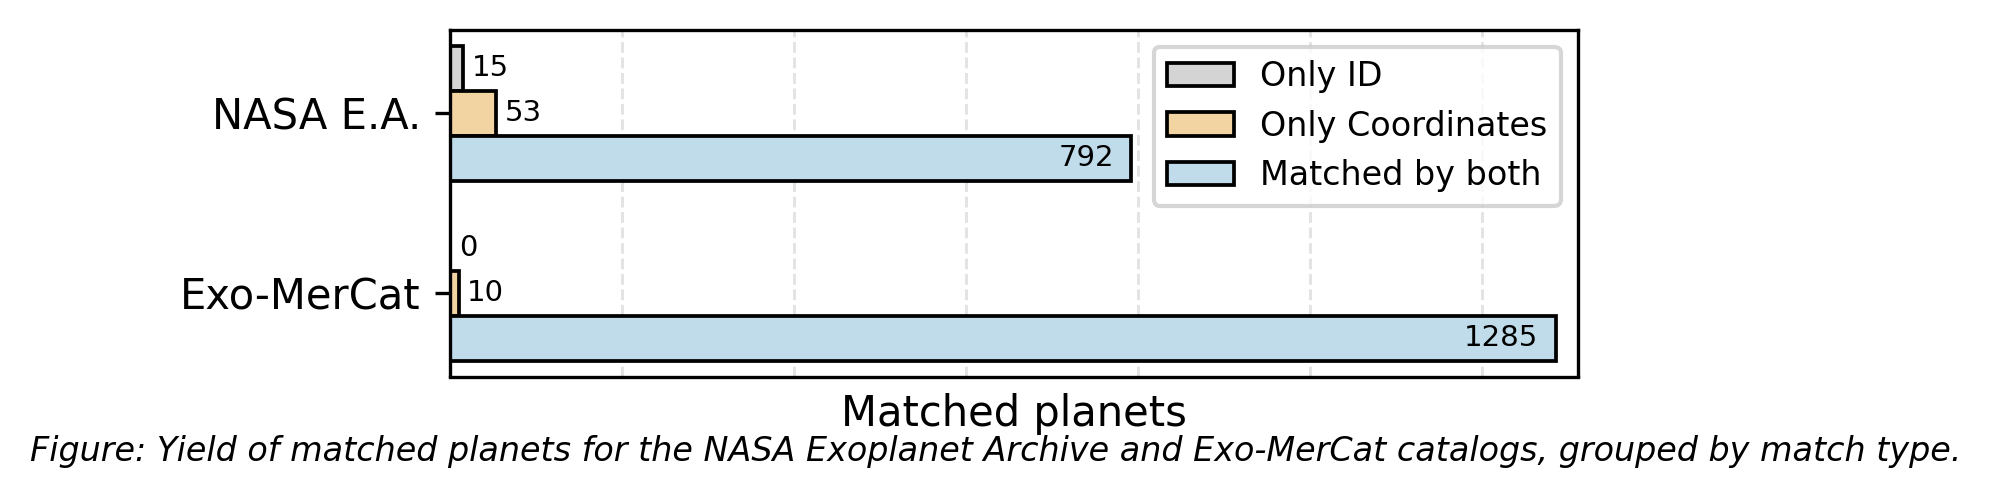

In [ ]:
catalog_names = ["NASA E.A.", "Exo-MerCat"]
match_types = ["id", "coordinates", "id+coordinates"]
match_labels = ["Only ID", "Only Coordinates", "Matched by both"]
values = np.array([
    [nea_matches.get(match_type, 0) for match_type in match_types],
    [emc_matches.get(match_type, 0) for match_type in match_types],
])

x = np.arange(len(catalog_names))
height = 0.25

fig, ax = plt.subplots(figsize=(4.85, 1.5))

colors = {
    "id": "#D4D4D4",
    "coordinates": "#F2D3A2",
    "id+coordinates": "#C0DCEB",
}

bars = []
for i, match_type in enumerate(match_types):
    for j, catalog_name in enumerate(catalog_names):
        bars.append(
            ax.barh(
                x[j] + (i - 1) * height,
                values[j, i],
                height,
                color=colors[match_type],
                edgecolor="black",
                linewidth=0.9,
            )
        )

ax.set_yticks(x)
ax.set_yticklabels(catalog_names)
ax.invert_yaxis()
ax.set_xlabel("Matched planets")
ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.35)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=colors[match_type], edgecolor="black", linewidth=0.9, label=label)
    for match_type, label in zip(match_types, match_labels)
]
ax.legend(
    legend_handles,
    match_labels,
    frameon=True,
    fancybox=True,
    fontsize=8,
)

for bars_group in bars:
    for bar in bars_group:
        width = int(bar.get_width())
        innie = width > 200
        ax.text(
            width + (10 if not innie else -20),
            bar.get_y() + bar.get_height() / 2,
            f"{width}",
            va="center",
            ha="left" if not innie else "right",
            fontsize=7,
            color="black",
        )

ax.set_xlim(0, max(values.max(), 1) * 1.02)
plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

plt.savefig("./notebooks/plots/yield.pdf", bbox_inches="tight", dpi=300)
